In [ ]:
Implement data loading, cleaning nad exploratory data analysis(eda) on a given dataset using numpy, pandas and matplotlib - handling missing values, summary statistics, distribution and correlation plots

Dataset loaded successfully!

First 5 rows:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1

Shape of dataset:
(418, 2)

Column names:
['PassengerId', 'Survived']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB

Data types:
PassengerId    int64
Survived       int64
dtype: object

Number of duplicate rows:
0
Shape after removing duplicates:
(418, 2)

Missing values in each column:
PassengerId    0
Survived       0
dtype: int64

Percentage of missing values:
PassengerId    0.0
Survived       0.0
dtype: float64

Missing values after cleaning:
PassengerId    0
Survived       0
dtype: int64

Summary statistics:
       P

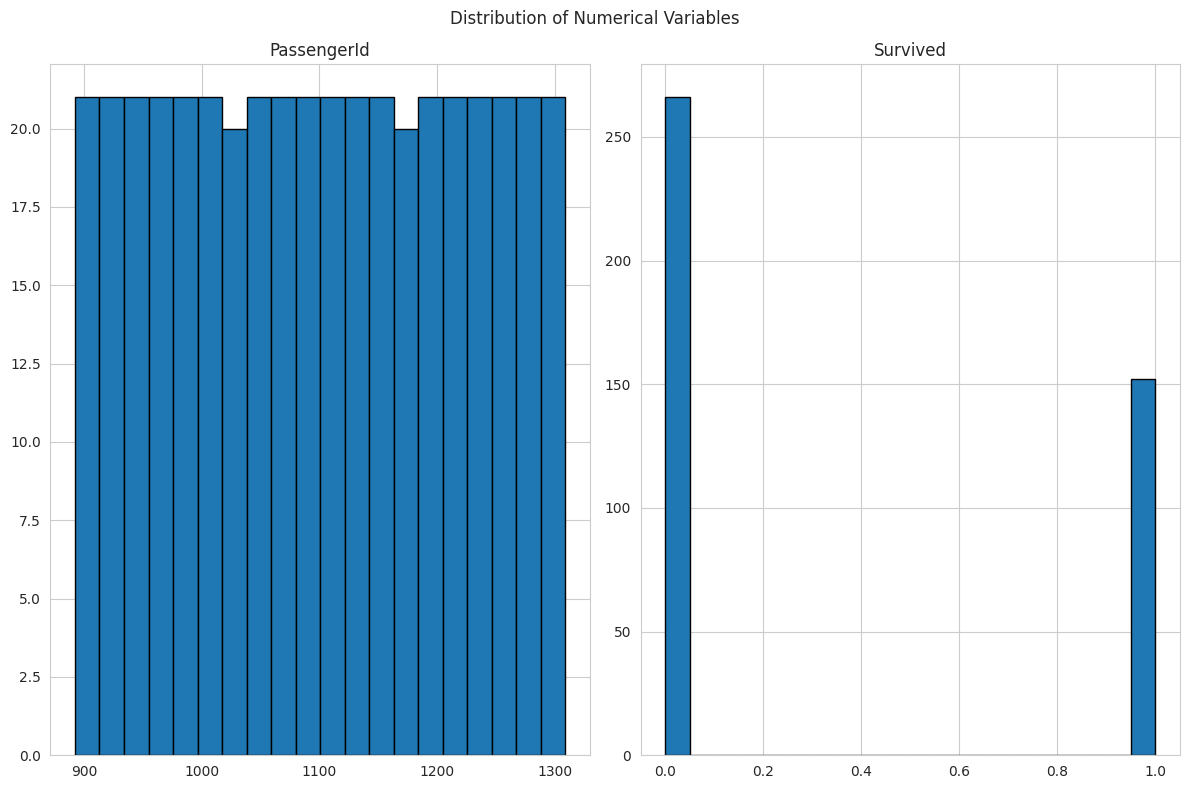

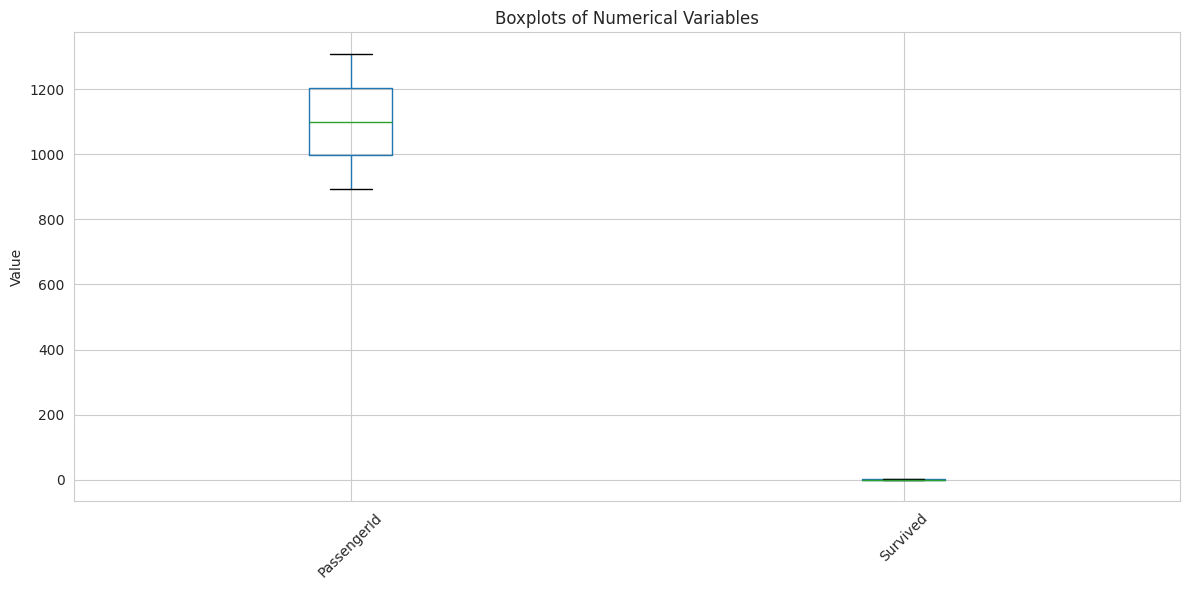


Outlier analysis:
PassengerId: 0 outliers
Survived: 0 outliers

Correlation matrix:
             PassengerId  Survived
PassengerId     1.000000 -0.023245
Survived       -0.023245  1.000000


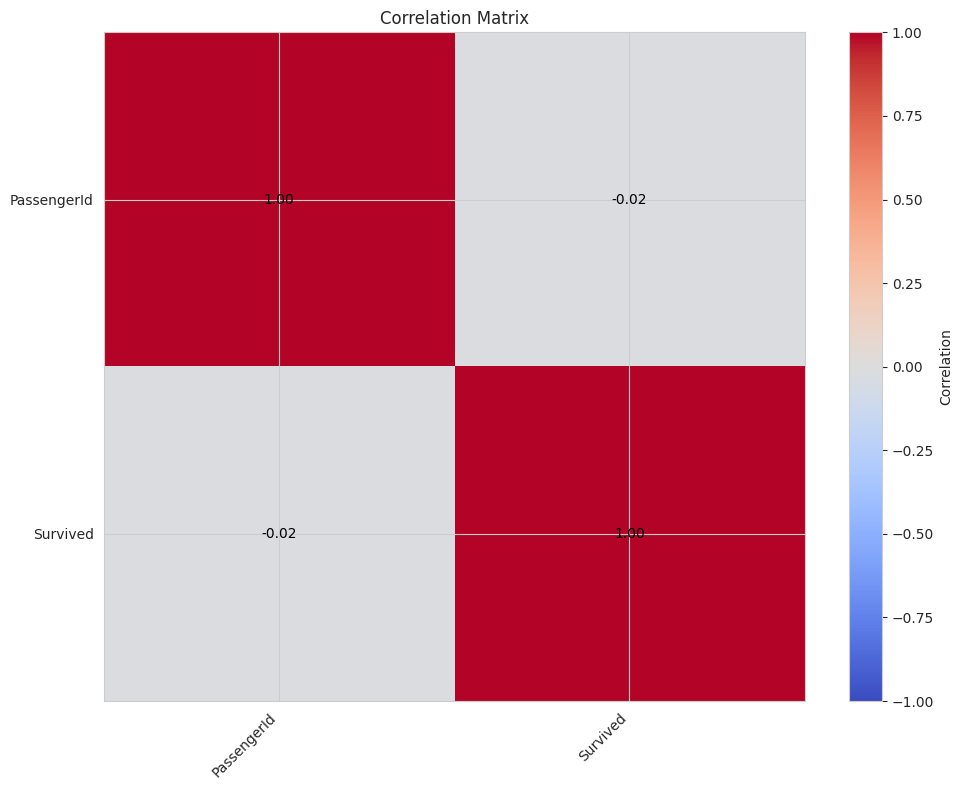


Strongest correlation: PassengerId vs Survived
Correlation coefficient: -0.023245135159774496


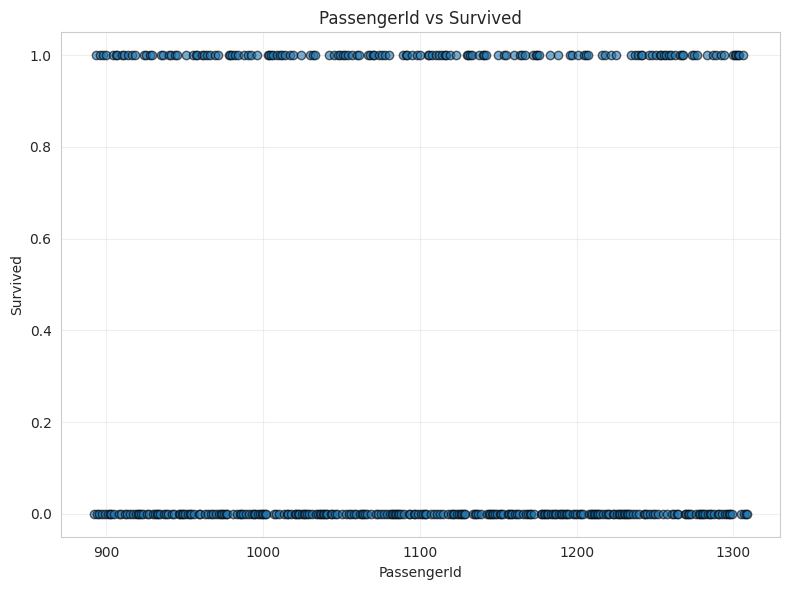


Final dataset:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1

Final shape:
(418, 2)

Remaining missing values:
PassengerId    0
Survived       0
dtype: int64

Cleaned dataset saved as 'cleaned_dataset.csv'


In [ ]:
# ============================================
# DATA LOADING, CLEANING AND EDA
# Using NumPy, Pandas and Matplotlib
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. LOAD THE DATASET
# --------------------------------------------

# Replace with your dataset path
file_path = "/content/gender_submission.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
print(df.head())


# --------------------------------------------
# 2. BASIC DATASET INFORMATION
# --------------------------------------------

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nData types:")
print(df.dtypes)


# --------------------------------------------
# 3. CHECK FOR DUPLICATE ROWS
# --------------------------------------------

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)


# --------------------------------------------
# 4. CHECK FOR MISSING VALUES
# --------------------------------------------

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nPercentage of missing values:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)


# --------------------------------------------
# 5. HANDLE MISSING VALUES
# --------------------------------------------

# Separate numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns

# Fill numerical missing values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())


# --------------------------------------------
# 6. SUMMARY STATISTICS
# --------------------------------------------

print("\nSummary statistics:")
print(df.describe())

print("\nSummary statistics including categorical columns:")
print(df.describe(include="all"))


# --------------------------------------------
# 7. NUMPY-BASED STATISTICS
# --------------------------------------------

print("\nNumerical columns:")
print(numeric_columns.tolist())

for col in numeric_columns:
    values = df[col].dropna().to_numpy()

    print(f"\nStatistics for {col}")
    print("Mean   :", np.mean(values))
    print("Median :", np.median(values))
    print("Std    :", np.std(values))
    print("Min    :", np.min(values))
    print("Max    :", np.max(values))


# --------------------------------------------
# 8. DISTRIBUTION PLOTS
# --------------------------------------------

# Histograms for numerical variables
df[numeric_columns].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()


# --------------------------------------------
# 9. BOX PLOTS
# --------------------------------------------

plt.figure(figsize=(12, 6))

df[numeric_columns].boxplot()

plt.title("Boxplots of Numerical Variables")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --------------------------------------------
# 10. OUTLIER DETECTION USING IQR
# --------------------------------------------

print("\nOutlier analysis:")

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")


# --------------------------------------------
# 11. CORRELATION MATRIX
# --------------------------------------------

correlation_matrix = df[numeric_columns].corr()

print("\nCorrelation matrix:")
print(correlation_matrix)


# --------------------------------------------
# 12. CORRELATION HEATMAP USING MATPLOTLIB
# --------------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="none",
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Add correlation values to cells
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# --------------------------------------------
# 13. SCATTER PLOT FOR HIGHLY CORRELATED VARIABLES
# --------------------------------------------

# Automatically find the strongest pair of numerical variables
corr = correlation_matrix.abs()

# Remove self-correlations
np.fill_diagonal(corr.values, 0)

max_pair = corr.stack().idxmax()

x_col = max_pair[0]
y_col = max_pair[1]

print(f"\nStrongest correlation: {x_col} vs {y_col}")
print(
    "Correlation coefficient:",
    correlation_matrix.loc[x_col, y_col]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    df[x_col],
    df[y_col],
    alpha=0.6,
    edgecolors="black"
)

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"{x_col} vs {y_col}")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --------------------------------------------
# 14. FINAL CLEANED DATASET
# --------------------------------------------

print("\nFinal dataset:")
print(df.head())

print("\nFinal shape:")
print(df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum())


# --------------------------------------------
# 15. SAVE CLEANED DATASET
# --------------------------------------------

df.to_csv("cleaned_dataset.csv", index=False)

print("\nCleaned dataset saved as 'cleaned_dataset.csv'")